In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon, Point
import spatialdata as sd
import squidpy as sq

c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sdata = sd.read_zarr('Version 1 Zarr//Sample1H_annotated.zarr')
sdata

SpatialData object with:
├── Images
│     ├── '1.1H.tiff': MultiscaleSpatialImage[cyx] (4, 758, 516), (4, 379, 258), (4, 189, 129), (4, 94, 64)
│     └── 'morphology_focus': MultiscaleSpatialImage[cyx] (1, 17102, 28466), (1, 8551, 14233), (1, 4275, 7116), (1, 2137, 3558), (1, 1068, 1779)
├── Labels
│     ├── 'cell_labels': MultiscaleSpatialImage[yx] (17102, 28466), (8551, 14233), (4275, 7116), (2137, 3558), (1068, 1779)
│     └── 'nucleus_labels': MultiscaleSpatialImage[yx] (17102, 28466), (8551, 14233), (4275, 7116), (2137, 3558), (1068, 1779)
├── Points
│     ├── 'HE_landmarks': DataFrame with shape: (5, 2) (2D points)
│     ├── 'Xenium_landmarks': DataFrame with shape: (5, 2) (2D points)
│     └── 'transcripts': DataFrame with shape: (505947, 10) (3D points)
├── Shapes
│     ├── 'Intima': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Media': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'cell_boundaries': GeoDataFrame shape: (6576, 1) (2D shapes)
│     ├── 'cell_circles': Geo

In [3]:
sdata.tables["table"].obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,cell_labels
0,aaakdhol-1,0,0,0,0,0,0,435.080485,12.688907,cell_circles,1
1,aaamccie-1,0,0,0,0,0,0,317.042043,78.887972,cell_circles,2
2,aacokdbe-1,1,0,0,0,0,1,327.111887,41.498595,cell_circles,3
3,aaebdfkm-1,1,0,0,0,0,1,881.224251,10.656875,cell_circles,4
4,aafehgia-1,0,0,0,0,0,0,771.133309,18.423751,cell_circles,5
...,...,...,...,...,...,...,...,...,...,...,...
6571,oipehlfh-1,58,0,0,0,0,58,342.826262,13.185625,cell_circles,6572
6572,ojadncgl-1,39,0,0,0,0,39,390.240327,17.340001,cell_circles,6573
6573,ojbdabcg-1,91,0,0,0,0,91,603.693928,34.138126,cell_circles,6574
6574,ojchjkjn-1,150,0,0,0,0,150,973.613942,59.606252,cell_circles,6575


In [5]:
cell_coords = sdata.tables["table"].obsm["spatial"]
Intima = sdata.shapes["Intima"].iloc[0, 0]
Media = sdata.shapes["Media"].iloc[0, 0]

In [6]:
def get_region(point, polygon1, polygon2):
    point = Point(point)
    if polygon1.contains(point):
        return "Intima"
    elif polygon2.contains(point):
        return "Media"
    else:
        return "None"

In [8]:
sdata.tables["table"].obs['plaque_region'] = [get_region(coord, Intima, Media) for coord in cell_coords]
sdata.tables["table"].obs['plaque_region'] = sdata.tables["table"].obs['plaque_region'].astype('category')

C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


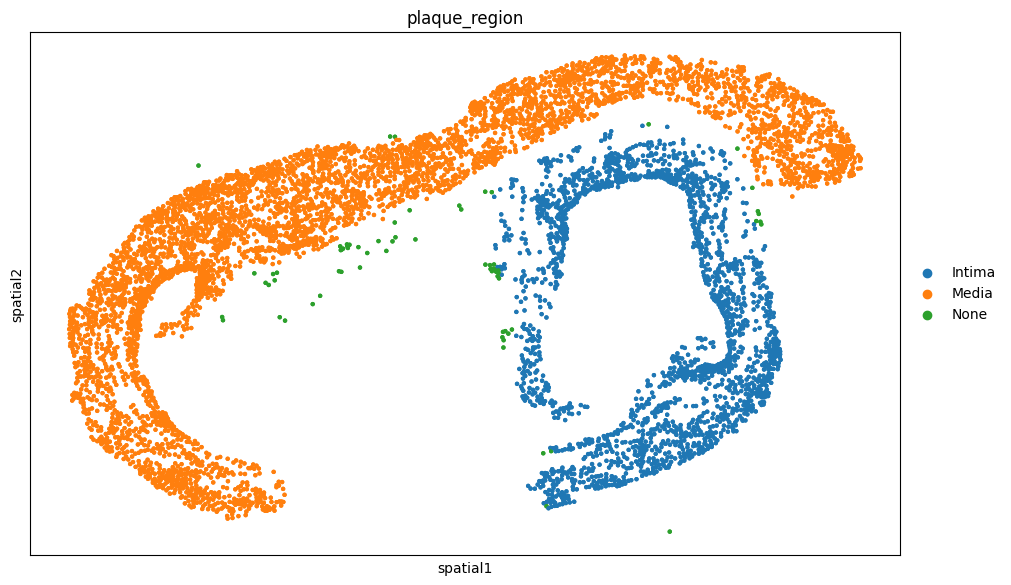

In [11]:
sq.pl.spatial_scatter(
    sdata.tables["table"], color=["plaque_region"], shape=None, figsize=(10, 10)
)

In [12]:
def find_closest_region(point, polygon1, polygon2):
    point = Point(point)
    dist_to_region1 = point.distance(polygon1)
    dist_to_region2 = point.distance(polygon2)
    if dist_to_region1 < dist_to_region2:
        return "Intima"
    else:
        return "Media"

In [22]:
for i, row in sdata.tables["table"].obs.iterrows():
    if row['plaque_region'] == 'None':
        sdata.tables["table"].obs.at[i, 'plaque_region'] = find_closest_region(cell_coords[int(i)], Intima, Media)

In [1]:
sq.pl.spatial_scatter(
    sdata.tables["table"], color=["plaque_region"], shape=None, figsize=(10, 10)
)

NameError: name 'sq' is not defined

In [18]:
sdata.tables["table"].obs["region"].unique()

['cell_circles']
Categories (1, object): ['cell_circles']

In [24]:
sdata.write("Sample1H_annotated.zarr")

INFO     The Zarr file used for backing will now change from Version 1 Zarr\Sample1H_annotated.zarr to             
         Sample1H_annotated.zarr                                                                                   
